**Table of contents**<a id='toc0_'></a>    
- 1. [Problem 1: Production economy and CO2 taxation](#toc1_)    
- 2. [Problem 2: Career choice model](#toc2_)    
- 3. [Problem 3: Barycentric interpolation](#toc3_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [2]:
# Write your code here
import numpy as np
from types import SimpleNamespace

## 1. <a id='toc1_'></a>[Problem 1: Production economy and CO2 taxation](#toc0_)

Consider a production economy with two firms indexed by $j \in \{1,2\}$. Each produce its own good. They solve

$$
\begin{align*}
\max_{y_{j}}\pi_{j}&=p_{j}y_{j}-w_{j}\ell_{j}\\\text{s.t.}\;&y_{j}=A\ell_{j}^{\gamma}.
\end{align*}
$$

Optimal firm behavior is

$$
\begin{align*}
\ell_{j}^{\star}(w,p_{j})&=\left(\frac{p_{j}A\gamma}{w}\right)^{\frac{1}{1-\gamma}} \\
y_{j}^{\star}(w,p_{j})&=A\left(\ell_{j}^{\star}(w,p_{j})\right)^{\gamma}
\end{align*}
$$

The implied profits are

$$
\pi_{j}^*(w,p_{j})=\frac{1-\gamma}{\gamma}w\cdot\left(\frac{p_{j}A\gamma}{w}\right)^{\frac{1}{1-\gamma}}
$$

A single consumer supplies labor, and consumes the goods the firms produce. She also recieves the implied profits of the firm.<br>
She solves:

$$
\begin{align*}
U(p_1,p_2,w,\tau,T) = \max_{c_{1},c_{2},\ell} & \log(c_{1}^{\alpha}c_{2}^{1-\alpha})-\nu\frac{\ell^{1+\epsilon}}{1+\epsilon} \\
\text{s.t.}\,\,\,&p_{1}c_{1}+(p_{2}+\tau)c_{2}=w\ell+T+\pi_{1}^*(w,p_{1})+\pi_{2}^*(w,p_{2})
\end{align*}
$$

where $\tau$ is a tax and $T$ is lump-sum transfer. <br>
For a given $\ell$, it can be shown that optimal behavior is

$$
\begin{align*}
c_{1}(\ell)&=\alpha\frac{w\ell+T+\pi_{1}^*(w,p_{1})+\pi_{2}^*(w,p_{2})}{p_{1}} \\
c_{2}(\ell)&=(1-\alpha)\frac{w\ell+T+\pi_{1}^*(w,p_{1})+\pi_{2}^*(w,p_{2})}{p_{2}+\tau} \\
\end{align*}
$$
Such that optimal behavior is:
$$
\ell^* = \underset{\ell}{\arg\max} \log(\left(c_{1}(\ell)\right)^{\alpha}\cdot \left(c_{2}(\ell)\right)^{1-\alpha})-\nu\frac{\ell^{1+\epsilon}}{1+\epsilon} 
$$
With optimal consumption:
$$
\begin{align*}
c_1^*=c_{1}(\ell^*) \\
c_2^*=c_{2}(\ell^*)\\
\end{align*}
$$


The government chooses $\tau$ and balances its budget so $T=\tau c_2^*$. We initially set $\tau,T=0$.

Market clearing requires:

1. Labor market: $\ell^* = \ell_1^* + \ell_2^*$
1. Good market 1: $c_1^* = y_1^*$
1. Good market 2: $c_2^* = y_2^*$


**Question 1:** Check market clearing conditions for $p_1$ in `linspace(0.1,2.0,10)` and $p_2$ in `linspace(0.1,2.0,10)`. We choose $w=1$ as numeraire.

In [3]:
par = SimpleNamespace()

# firms
par.A = 1.0
par.gamma = 0.5

# households
par.alpha = 0.3
par.nu = 1.0
par.epsilon = 2.0

# government
par.tau = 0.0
par.T = 0.0

# Question 3
par.kappa = 0.1

In [4]:
import numpy as np
from types import SimpleNamespace
import pandas as pd

# Define parameters
par = SimpleNamespace()
par.A = 1.0
par.gamma = 0.5
par.alpha = 0.3
par.nu = 1.0
par.epsilon = 2.0
par.tau = 0.0
par.T = 0.0

# Define ranges for p1 and p2
p1_values = np.linspace(0.1, 2.0, 10)
p2_values = np.linspace(0.1, 2.0, 10)

# Helper functions
def optimal_labor(w, p, A, gamma):
    return (p * A * gamma / w)**(1 / (1 - gamma))

def production(l, A, gamma):
    return A * l**gamma

def profit(w, p, A, gamma):
    return (1 - gamma) * (p * A * gamma / w)**(gamma / (1 - gamma))

def consumer_utility(p1, p2, w, tau, T, alpha, nu, epsilon):
    labor = ((w * alpha + T + profit(w, p1, par.A, par.gamma) + profit(w, p2, par.A, par.gamma)) / (nu * (1 + epsilon)))**(1 / (1 + epsilon))
    c1 = alpha * (w * labor + T + profit(w, p1, par.A, par.gamma) + profit(w, p2, par.A, par.gamma)) / p1
    c2 = (1 - alpha) * (w * labor + T + profit(w, p1, par.A, par.gamma) + profit(w, p2, par.A, par.gamma)) / (p2 + tau)
    return labor, c1, c2

# Market clearing check
results = []
for p1 in p1_values:
    for p2 in p2_values:
        w = 1  # Numeraire
        labor, c1, c2 = consumer_utility(p1, p2, w, par.tau, par.T, par.alpha, par.nu, par.epsilon)
        l1 = optimal_labor(w, p1, par.A, par.gamma)
        l2 = optimal_labor(w, p2, par.A, par.gamma)
        y1 = production(l1, par.A, par.gamma)
        y2 = production(l2, par.A, par.gamma)
        labor_market_clearing = np.isclose(labor, l1 + l2)
        goods_market1_clearing = np.isclose(c1, y1)
        goods_market2_clearing = np.isclose(c2, y2)
        results.append((p1, p2, labor_market_clearing, goods_market1_clearing, goods_market2_clearing))

# Display results
results_df = pd.DataFrame(results, columns=['p1', 'p2', 'Labor Market Clearing', 'Goods Market 1 Clearing', 'Goods Market 2 Clearing'])
print(results_df)

     p1        p2  Labor Market Clearing  Goods Market 1 Clearing  \
0   0.1  0.100000                  False                    False   
1   0.1  0.311111                  False                    False   
2   0.1  0.522222                  False                    False   
3   0.1  0.733333                  False                    False   
4   0.1  0.944444                  False                    False   
..  ...       ...                    ...                      ...   
95  2.0  1.155556                  False                    False   
96  2.0  1.366667                  False                    False   
97  2.0  1.577778                  False                    False   
98  2.0  1.788889                  False                    False   
99  2.0  2.000000                  False                    False   

    Goods Market 2 Clearing  
0                     False  
1                     False  
2                     False  
3                     False  
4                    

**Question 2:** Find the equilibrium prices $p_1$ and $p_2$.<br>
*Hint: you can use Walras' law to only check 2 of the market clearings*

In [5]:
import numpy as np
from scipy.optimize import fsolve
from types import SimpleNamespace

# Define parameters
par = SimpleNamespace()
par.A = 1.0
par.gamma = 0.5
par.alpha = 0.3
par.nu = 1.0
par.epsilon = 2.0
par.tau = 0.0
par.T = 0.0

# Helper functions
def optimal_labor(w, p, A, gamma):
    return (p * A * gamma / w)**(1 / (1 - gamma))

def production(l, A, gamma):
    return A * l**gamma

def profit(w, p, A, gamma):
    return (1 - gamma) * (p * A * gamma / w)**(gamma / (1 - gamma))

def consumer_utility(p1, p2, w, tau, T, alpha, nu, epsilon):
    labor = ((w * alpha + T + profit(w, p1, par.A, par.gamma) + profit(w, p2, par.A, par.gamma)) / (nu * (1 + epsilon)))**(1 / (1 + epsilon))
    c1 = alpha * (w * labor + T + profit(w, p1, par.A, par.gamma) + profit(w, p2, par.A, par.gamma)) / p1
    c2 = (1 - alpha) * (w * labor + T + profit(w, p1, par.A, par.gamma) + profit(w, p2, par.A, par.gamma)) / (p2 + tau)
    return labor, c1, c2

# Market clearing functions
def labor_market_clearing(labor, l1, l2):
    return labor - (l1 + l2)

def goods_market_clearing(c, y):
    return c - y

# Define the system of equations to solve
def equations(prices):
    p1, p2 = prices
    w = 1  # Numeraire
    labor, c1, c2 = consumer_utility(p1, p2, w, par.tau, par.T, par.alpha, par.nu, par.epsilon)
    l1 = optimal_labor(w, p1, par.A, par.gamma)
    l2 = optimal_labor(w, p2, par.A, par.gamma)
    y1 = production(l1, par.A, par.gamma)
    y2 = production(l2, par.A, par.gamma)
    
    eq1 = labor_market_clearing(labor, l1, l2)
    eq2 = goods_market_clearing(c1, y1)
    eq3 = goods_market_clearing(c2, y2)
    
    # Using Walras' law, we only need two of these conditions
    return [eq1, eq2]

# Initial guess for the prices
initial_guess = [1.0, 1.0]

# Solve the system of equations
equilibrium_prices = fsolve(equations, initial_guess)
p1_eq, p2_eq = equilibrium_prices

print(f"Equilibrium prices: p1 = {p1_eq}, p2 = {p2_eq}")

Equilibrium prices: p1 = 0.8548215082956273, p2 = 1.3804052987653903


# check if true

In [6]:
import numpy as np
from scipy.optimize import fsolve
from types import SimpleNamespace

# Define parameters
par = SimpleNamespace()
par.A = 1.0
par.gamma = 0.5
par.alpha = 0.3
par.nu = 1.0
par.epsilon = 2.0
par.tau = 0.0
par.T = 0.0

# Helper functions
def optimal_labor(w, p, A, gamma):
    return (p * A * gamma / w)**(1 / (1 - gamma))

def production(l, A, gamma):
    return A * l**gamma

def profit(w, p, A, gamma):
    return (1 - gamma) * (p * A * gamma / w)**(gamma / (1 - gamma))

def consumer_utility(p1, p2, w, tau, T, alpha, nu, epsilon):
    labor = ((w * alpha + T + profit(w, p1, par.A, par.gamma) + profit(w, p2, par.A, par.gamma)) / (nu * (1 + epsilon)))**(1 / (1 + epsilon))
    c1 = alpha * (w * labor + T + profit(w, p1, par.A, par.gamma) + profit(w, p2, par.A, par.gamma)) / p1
    c2 = (1 - alpha) * (w * labor + T + profit(w, p1, par.A, par.gamma) + profit(w, p2, par.A, par.gamma)) / (p2 + tau)
    return labor, c1, c2

# Market clearing functions
def labor_market_clearing(labor, l1, l2):
    return labor - (l1 + l2)

def goods_market_clearing(c, y):
    return c - y

# Define the system of equations to solve
def equations(prices):
    p1, p2 = prices
    w = 1  # Numeraire
    labor, c1, c2 = consumer_utility(p1, p2, w, par.tau, par.T, par.alpha, par.nu, par.epsilon)
    l1 = optimal_labor(w, p1, par.A, par.gamma)
    l2 = optimal_labor(w, p2, par.A, par.gamma)
    y1 = production(l1, par.A, par.gamma)
    y2 = production(l2, par.A, par.gamma)
    
    eq1 = labor_market_clearing(labor, l1, l2)
    eq2 = goods_market_clearing(c1, y1)
    eq3 = goods_market_clearing(c2, y2)
    
    # Using Walras' law, we only need two of these conditions
    return [eq1, eq2]

# Initial guess for the prices
initial_guess = [1.0, 1.0]

# Solve the system of equations
equilibrium_prices = fsolve(equations, initial_guess)
p1_eq, p2_eq = equilibrium_prices

# Check if the markets clear
w = 1  # Numeraire
labor, c1, c2 = consumer_utility(p1_eq, p2_eq, w, par.tau, par.T, par.alpha, par.nu, par.epsilon)
l1 = optimal_labor(w, p1_eq, par.A, par.gamma)
l2 = optimal_labor(w, p2_eq, par.A, par.gamma)
y1 = production(l1, par.A, par.gamma)
y2 = production(l2, par.A, par.gamma)

labor_market_clear = np.isclose(labor, l1 + l2)
goods_market1_clear = np.isclose(c1, y1)
goods_market2_clear = np.isclose(c2, y2)

print(f"Equilibrium prices: p1 = {p1_eq}, p2 = {p2_eq}")
print(f"Labor market clears: {labor_market_clear}")
print(f"Goods market 1 clears: {goods_market1_clear}")
print(f"Goods market 2 clears: {goods_market2_clear}")

Equilibrium prices: p1 = 0.8548215082956273, p2 = 1.3804052987653903
Labor market clears: True
Goods market 1 clears: True
Goods market 2 clears: False


Assume the government care about the social welfare function:

$$
SWF = U - \kappa y_2^*
$$

Here $\kappa$ measures the social cost of carbon emitted by the production of $y_2$ in equilibrium.

**Question 3:** What values of $\tau$ and (implied) $T$ should the government choose to maximize $SWF$?

In [7]:
# write your answer here

## 2. <a id='toc2_'></a>[Problem 2: Career choice model](#toc0_)

Consider a graduate $i$ making a choice between entering $J$ different career tracks. <br>
Entering career $j$ yields utility $u^k_{ij}$. This value is unknown to the graduate ex ante, but will ex post be: <br>
$$
    u_{i,j}^k = v_{j} + \epsilon_{i,j}^k
$$

They know that $\epsilon^k_{i,j}\sim \mathcal{N}(0,\sigma^2)$, but they do not observe $\epsilon^k_{i,j}$ before making their career choice. <br>

Consider the concrete case of $J=3$ with:
$$
\begin{align*}
    v_{1} &= 1 \\
    v_{2} &= 2 \\
    v_{3} &= 3
\end{align*}
$$

If the graduates know the values of $v_j$ and the distribution of $\epsilon_{i,j}^k$, they can calculate the expected utility of each career track using simulation: <br>
$$
    \mathbb{E}\left[ u^k_{i,j}\vert v_j \right] \approx v_j + \frac{1}{K}\sum_{k=1}^K \epsilon_{i,j}^k
$$

In [8]:
par = SimpleNamespace()
par.J = 3
par.N = 10
par.K = 10000

par.F = np.arange(1,par.N+1)
par.sigma = 2

par.v = np.array([1,2,3])
par.c = 1

**Question 1:** Simulate and calculate expected utility and the average realised utility for $K=10000$ draws, for each career choice $j$.


1. We simulate values of epsilon
2. Then calculating expected utilities by taking the mean of drawn epsilons
3. Then calculate average realized utlity for each career track.

In [9]:
from Problem2 import careermodelclass
import numpy as np

model = careermodelclass()

expected_utility = model.expected_utility()
print(f"Expected utility for each value in v is: {expected_utility} respectively")

realized_utility = model.realized_utility()

average_realized_utility = model.average_realized_utility()

for j in range(model.par.J):
    print(f"Career track {j+1}:")
    print(f"Average Realized Utility: {average_realized_utility[j]}")
    print()

Expected utility for each value in v is: [1.01194451 1.98151599 2.98481459] respectively
Career track 1:
Average Realized Utility: 0.9913240515451136

Career track 2:
Average Realized Utility: 1.985907158368285

Career track 3:
Average Realized Utility: 3.003599118550482



Now consider a new scenario: Imagine that the graduate does not know $v_j$. The *only* prior information they have on the value of each job, comes from their $F_{i}$ friends that work in each career $j$. After talking with them, they know the average utility of their friends (which includes their friends' noise term), giving them the prior expecation: <br>
$$
\tilde{u}^k_{i,j}\left( F_{i}\right) = \frac{1}{F_{i}}\sum_{f=1}^{F_{i}} \left(v_{j} + \epsilon^k_{f,j}\right), \; \epsilon^k_{f,j}\sim \mathcal{N}(0,\sigma^2)
$$
For ease of notation consider that each graduate have $F_{i}=i$ friends in each career. <br>

For $K$ times do the following: <br>
1. For each person $i$ draw $J\cdot F_i$ values of $\epsilon_{f,j}^{k}$, and calculate the prior expected utility of each career track, $\tilde{u}^k_{i,j}\left( F_{i}\right)$. <br>
Also draw their own $J$ noise terms, $\epsilon_{i,j}^k$
1. Each person $i$ chooses the career track with the highest expected utility: $$j_i^{k*}= \arg\max_{j\in{1,2\dots,J}}\left\{ \tilde{u}^k_{i,j}\left( F_{i}\right)\right\} $$
1. Store the chosen careers: $j_i^{k*}$, the prior expectation of the value of their chosen career: $\tilde{u}^k_{i,j=j_i^{k*}}\left( F_{i}\right)$, and the realized value of their chosen career track: $u^k_{i,j=j_i^{k*}}=v_{j=j_i^{k*}}+\epsilon_{i,j=j_i^{k*}}^k$.

Chosen values will be: <br>
$i\in\left\{1,2\dots,N\right\}, N=10$ <br>
$F_i = i$<br>
So there are 10 graduates. The first has 1 friend in each career, the second has 2 friends, ... the tenth has 10 friends.

**Question 2:** Simulate and visualize: For each type of graduate, $i$, the share of graduates choosing each career, the average subjective expected utility of the graduates, and the average ex post realized utility given their choice. <br>
That is, calculate and visualize: <br>
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} \mathbb{I}\left\{ j=j_i^{k*} \right\}  \;\forall j\in\left\{1,2,\dots,J\right\}
\end{align*}
$$
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} \tilde{u}^k_{ij=j_i^{k*}}\left( F_{i}\right)
\end{align*}
$$
And 
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} u^k_{ij=j_i^{k*}} 
\end{align*}
$$
For each graduate $i$.

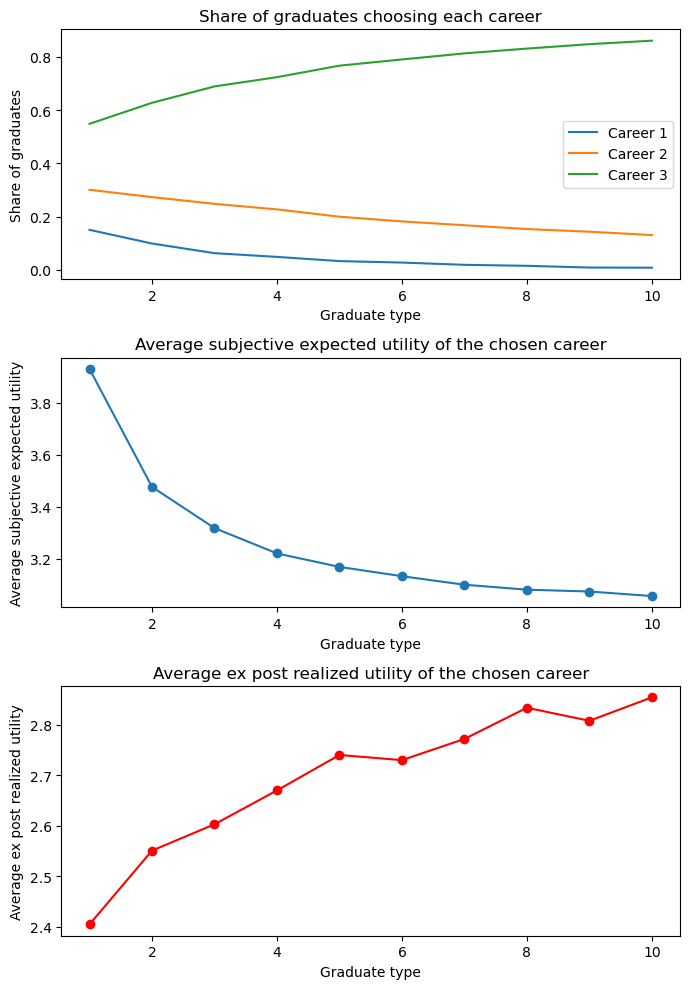

In [10]:
import matplotlib.pyplot as plt

chosen_careers = np.zeros((par.N, par.K), dtype=int)
prior_expected_utilities = np.zeros((par.N, par.K))
realized_utilities = np.zeros((par.N, par.K))

for k in range(par.K):
    for i in range(1, par.N+1):
        # We define the number of friends for each graduate
        F_i = i

        # Then draw epsilon values for friends for J*F_i times.
        epsilon_friends = np.random.normal(0, par.sigma, (par.J, F_i))

        # Calculate prior expected utility for each career track
        prior_expected_utility = par.v + np.mean(epsilon_friends, axis=1)

        # Draw epsilon values for the graduate
        epsilon_i = np.random.normal(0, par.sigma, par.J)

        # We find the carrer tha maximizes the prior expected utility, which the graduate will choose
        chosen_career = np.argmax(prior_expected_utility)
        chosen_careers[i-1, k] = chosen_career

        # Storing our found resulsts
        prior_expected_utilities[i-1, k] = prior_expected_utility[chosen_career]

        # finally, we calculate realized utility for the chosen career
        realized_utilities[i-1, k] = par.v[chosen_career] + epsilon_i[chosen_career]
# Source: ChatGPT has been used as a refrerence to help develop the for-loop above.

# Now we calculate the share of graduates choosing each career for each type of graduate
shares = np.zeros((par.N, par.J))
for i in range(par.N):
    for j in range(par.J):
        shares[i, j] = np.mean(chosen_careers[i] == j)

average_subjective_expected_utilities = np.mean(prior_expected_utilities, axis=1)

average_realized_utilities = np.mean(realized_utilities, axis=1)


# We plot the share of graduates choosing each career respectively
fig, ax = plt.subplots(3, 1, figsize=(7, 10))

x = np.arange(1, par.N + 1)

for j in range(par.J):
    ax[0].plot(x, shares[:, j], label=f'Career {j+1}')
ax[0].set_xlabel('Graduate type')
ax[0].set_ylabel('Share of graduates')
ax[0].legend()
ax[0].set_title('Share of graduates choosing each career')

ax[1].plot(x, average_subjective_expected_utilities, marker='o')
ax[1].set_xlabel('Graduate type')
ax[1].set_ylabel('Average subjective expected utility')
ax[1].set_title('Average subjective expected utility of the chosen career')

ax[2].plot(x, average_realized_utilities, marker='o', color='r')
ax[2].set_xlabel('Graduate type')
ax[2].set_ylabel('Average ex post realized utility')
ax[2].set_title('Average ex post realized utility of the chosen career')

plt.tight_layout()
plt.show()



After a year of working in their career, the graduates learn $u^k_{ij}$ for their chosen job $j_i^{k*}$ perfectly. <br>
The can switch to one of the two remaining careers, for which they have the same prior as before, but it will now include a switching cost of $c$ which is known.
Their new priors can be written as: 
$$
\tilde{u}^{k,2}_{ij}\left( F_{i}\right) = \begin{cases}
            \tilde{u}^k_{ij}\left( F_{i}\right)-c & \text{if } j \neq j_i^{k*} \\
            u_{ij=j_i^{k*}} & \text{if } j = j_i^{k*}
        \end{cases}
$$

We will set $c=1$.

Their realized utility will be: <br>
$$
u^{k,2}_{ij}= \begin{cases}
            u_{ij}^k -c & \text{if } j \neq j_i^{k*} \\
            u_{ij=j_i^{k*}} & \text{if } j = j_i^{k*}
        \end{cases}
$$

**Question 3:** Following the same approach as in question 2, find the new optimal career choice for each $i$, $k$. Then for each $i$, calculate the average subjective expected utility from their new optimal career choice, and the ex post realized utility of that career. Also, for each $i$, calculate the share of graduates that chooses to switch careers, conditional on which career they chose in the first year. <br>

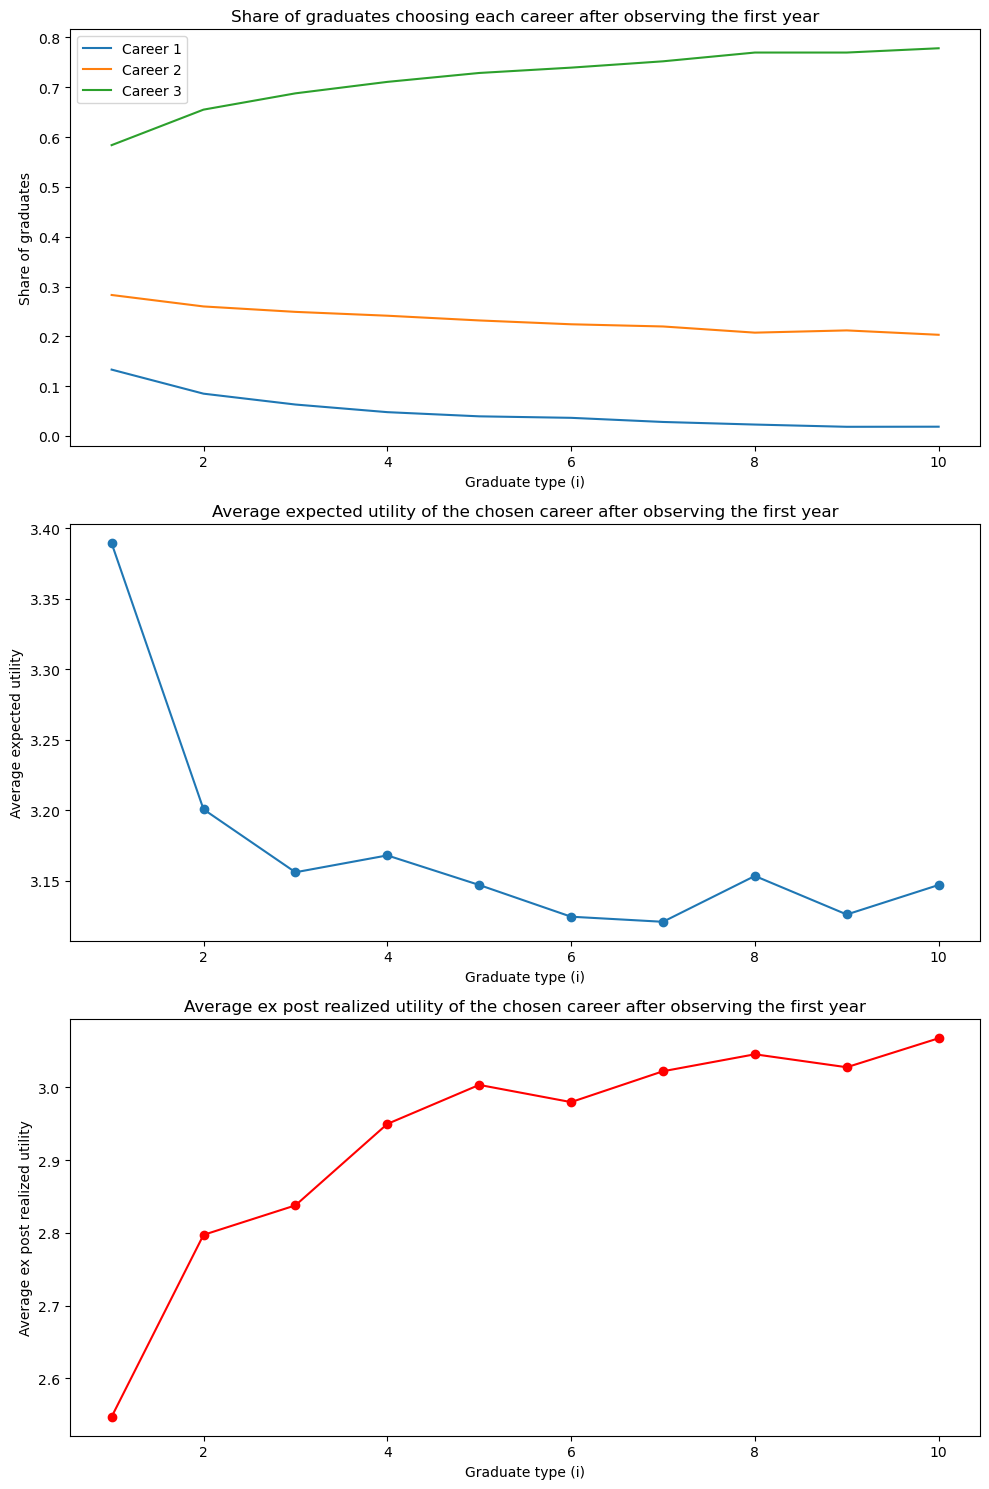

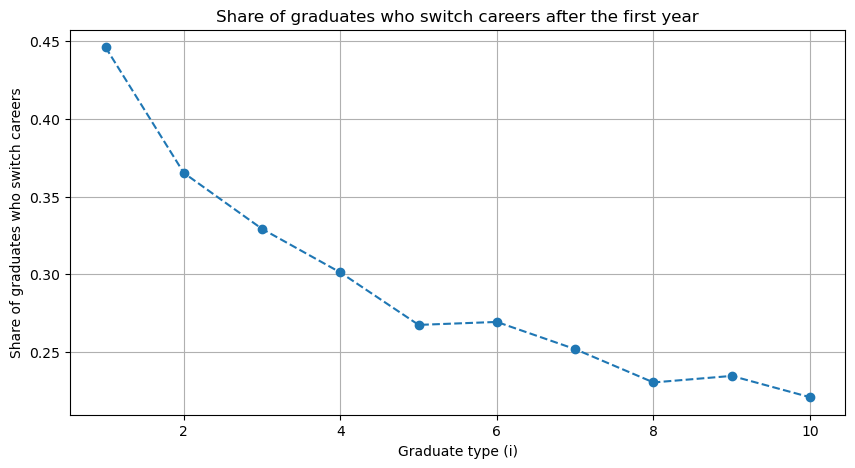

In [11]:

# We store our results in the arrays for the carrerpaths after a year of working
new_chosen_careers = np.zeros((par.N, par.K), dtype=int)
new_prior_expected_utilities = np.zeros((par.N, par.K))
new_realized_utilities = np.zeros((par.N, par.K))
switch_decision = np.zeros((par.N, par.K), dtype=bool)

# Simulation loop for the second round
for k in range(par.K):
    for i in range(1, par.N + 1):
        chosen_career = chosen_careers[i-1, k]
        initial_realized_utility = realized_utilities[i-1, k]

        # Draw epsilon values for friends again for the two remaining careers
        epsilon_friends = np.random.normal(0, par.sigma, (par.J, i))

        # Calculate new prior expected utility for each career track
        new_prior_expected_utility = par.v + np.mean(epsilon_friends, axis=1)
        new_prior_expected_utility -= par.c  # Apply switching cost

        # Update the utility for the chosen career with the known value
        new_prior_expected_utility[chosen_career] = initial_realized_utility

        # Draw new epsilon values for the graduate for the remaining careers
        epsilon_i = np.random.normal(0, par.sigma, par.J)

        # Calculate new realized utilities
        new_realized_utility = par.v + epsilon_i
        new_realized_utility -= par.c  # Apply switching cost
        new_realized_utility[chosen_career] = initial_realized_utility

        # Choose the career track with the highest updated utility
        new_chosen_career = np.argmax(new_prior_expected_utility)
        new_chosen_careers[i-1, k] = new_chosen_career

        # Store the new prior expected utility of the chosen career
        new_prior_expected_utilities[i-1, k] = new_prior_expected_utility[new_chosen_career]

        # Store the new realized utility of the chosen career
        new_realized_utilities[i-1, k] = new_realized_utility[new_chosen_career]

        # Determine if the graduate decided to switch careers
        switch_decision[i-1, k] = (new_chosen_career != chosen_career)


# Calculate the share of graduates choosing each career for each type of graduate after obseriving the first year
new_shares = np.zeros((par.N, par.J))
for i in range(par.N):
    for j in range(par.J):
        new_shares[i, j] = np.mean(new_chosen_careers[i] == j)

# Calculate the average subjective expected utility for each type of graduate in the second round
new_average_expected_utilities = np.mean(new_prior_expected_utilities, axis=1)

# Calculate the average ex post realized utility for each type of graduate in the second round
new_average_realized_utilities = np.mean(new_realized_utilities, axis=1)

# Calculate the share of graduates who switch careers for each type of graduate
switch_shares = np.mean(switch_decision, axis=1)

# Time to visualize and plot our results
fig, ax = plt.subplots(3, 1, figsize=(10, 15))

x = np.arange(1, par.N + 1)


for j in range(par.J):
    ax[0].plot(x, new_shares[:, j], label=f'Career {j + 1}')
ax[0].set_xlabel('Graduate type (i)')
ax[0].set_ylabel('Share of graduates')
ax[0].legend()
ax[0].set_title('Share of graduates choosing each career after observing the first year')

ax[1].plot(x, new_average_expected_utilities, marker='o')
ax[1].set_xlabel('Graduate type (i)')
ax[1].set_ylabel('Average expected utility')
ax[1].set_title('Average expected utility of the chosen career after observing the first year')

ax[2].plot(x, new_average_realized_utilities, marker='o', color='r')
ax[2].set_xlabel('Graduate type (i)')
ax[2].set_ylabel('Average ex post realized utility')
ax[2].set_title('Average ex post realized utility of the chosen career after observing the first year')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(x, switch_shares, marker='o', linestyle='--')
plt.xlabel('Graduate type (i)')
plt.ylabel('Share of graduates who switch careers')
plt.title('Share of graduates who switch careers after the first year')
plt.grid(True)
plt.show()


## 3. <a id='toc3_'></a>[Problem 3: Barycentric interpolation](#toc0_)

**Problem:** We have a set of random points in the unit square,

$$
\mathcal{X} = \{(x_1,x_2)\,|\,x_1\sim\mathcal{U}(0,1),x_2\sim\mathcal{U}(0,1)\}.
$$

For these points, we know the value of some function $f(x_1,x_2)$,

$$
\mathcal{F} = \{f(x_1,x_2) \,|\, (x_1,x_2) \in \mathcal{X}\}.
$$

Now we want to approximate the value $f(y_1,y_2)$ for some  $y=(y_1,y_2)$, where $y_1\sim\mathcal{U}(0,1)$ and $y_2\sim\mathcal{U}(0,1)$.

**Building block I**

For an arbitrary triangle $ABC$ and a point $y$, define the so-called barycentric coordinates as:

$$
\begin{align*}
  r^{ABC}_1 &= \frac{(B_2-C_2)(y_1-C_1) + (C_1-B_1)(y_2-C_2)}{(B_2-C_2)(A_1-C_1) + (C_1-B_1)(A_2-C_2)} \\
  r^{ABC}_2 &= \frac{(C_2-A_2)(y_1-C_1) + (A_1-C_1)(y_2-C_2)}{(B_2-C_2)(A_1-C_1) + (C_1-B_1)(A_2-C_2)} \\
  r^{ABC}_3 &= 1 - r_1 - r_2.
\end{align*}
$$

If $r^{ABC}_1 \in [0,1]$, $r^{ABC}_2 \in [0,1]$, and $r^{ABC}_3 \in [0,1]$, then the point is inside the triangle.

We always have $y = r^{ABC}_1 A + r^{ABC}_2 B + r^{ABC}_3 C$.

**Building block II**

Define the following points:

$$
\begin{align*}
A&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}>y_{1}\text{ and }x_{2}>y_{2}\\
B&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}>y_{1}\text{ and }x_{2}<y_{2}\\
C&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}<y_{1}\text{ and }x_{2}<y_{2}\\
D&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}<y_{1}\text{ and }x_{2}>y_{2}.
\end{align*}
$$

**Algorithm:**

1. Compute $A$, $B$, $C$, and $D$. If not possible return `NaN`.
1. If $y$ is inside the triangle $ABC$ return $r^{ABC}_1 f(A) + r^{ABC}_2 f(B) + r^{ABC}_3 f(C)$.
1. If $y$ is inside the triangle $CDA$ return $r^{CDA}_1 f(C) + r^{CDA}_2 f(D) + r^{CDA}_3 f(A)$.
1. Return `NaN`.



**Sample:**

In [12]:
rng = np.random.default_rng(2024)

X = rng.uniform(size=(50,2))
y = rng.uniform(size=(2,))


**Questions 1:** Find $A$, $B$, $C$ and $D$. Illustrate these together with $X$, $y$ and the triangles $ABC$ and $CDA$.

A coordinates are [0.26071605 0.43635845]
B coordinates are [0.21315735 0.274245  ]
C coordinates are [0.10056103 0.27951775]
D coordinates are [0.20634391 0.44272557]


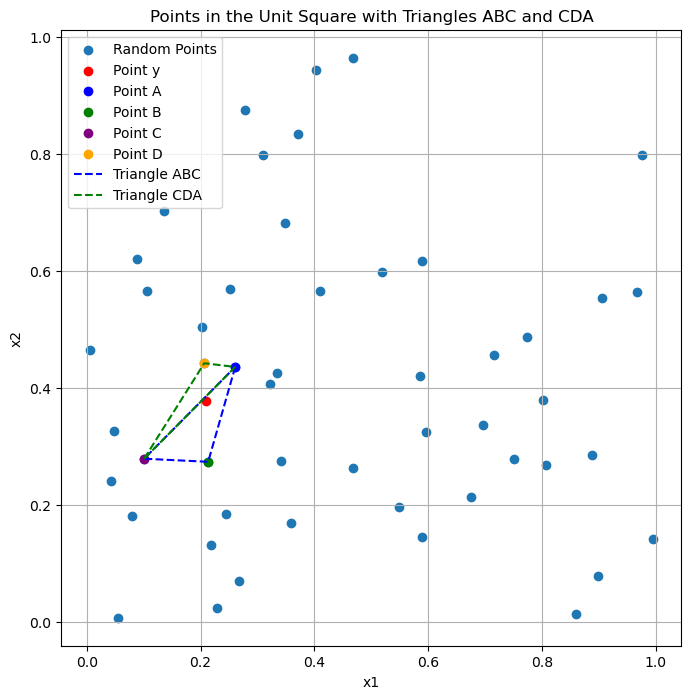

In [13]:
#Building block 1:
def barycentric_coords(y, A, B, C):
    denom = (B[1] - C[1]) * (A[0] - C[0]) + (C[0] - B[0]) * (A[1] - C[1])
    r1 = ((B[1] - C[1]) * (y[0] - C[0]) + (C[0] - B[0]) * (y[1] - C[1])) / denom
    r2 = ((C[1] - A[1]) * (y[0] - C[0]) + (A[0] - C[0]) * (y[1] - C[1])) / denom
    r3 = 1 - r1 - r2
    return r1, r2, r3

#Building block 2:
def find_A(X, y):
    candidates = X[(X[:,0] > y[0]) & (X[:,1] > y[1])]
    if len(candidates) == 0:
        return np.nan
    return candidates[np.argmin(np.linalg.norm(candidates - y, axis=1))]

def find_B(X, y):
    candidates = X[(X[:,0] > y[0]) & (X[:,1] < y[1])]
    if len(candidates) == 0:
        return np.nan
    return candidates[np.argmin(np.linalg.norm(candidates - y, axis=1))]

def find_C(X, y):
    candidates = X[(X[:,0] < y[0]) & (X[:,1] < y[1])]
    if len(candidates) == 0:
        return np.nan
    return candidates[np.argmin(np.linalg.norm(candidates - y, axis=1))]

def find_D(X, y):
    candidates = X[(X[:,0] < y[0]) & (X[:,1] > y[1])]
    if len(candidates) == 0:
        return np.nan
    return candidates[np.argmin(np.linalg.norm(candidates - y, axis=1))]


A = find_A(X, y)
B = find_B(X, y)
C = find_C(X, y)
D = find_D(X, y)

# Plotting
plt.figure(figsize=(8, 8))
plt.scatter(X[:,0], X[:,1], label='Random Points')
plt.scatter(y[0], y[1], color='red', label='Point y')
if not np.isnan(A).any():
    plt.scatter(A[0], A[1], color='blue', label='Point A')
if not np.isnan(B).any():
    plt.scatter(B[0], B[1], color='green', label='Point B')
if not np.isnan(C).any():
    plt.scatter(C[0], C[1], color='purple', label='Point C')
if not np.isnan(D).any():
    plt.scatter(D[0], D[1], color='orange', label='Point D')

# Draw triangles ABC and CDA if possible
if not np.isnan(A).any() and not np.isnan(B).any() and not np.isnan(C).any():
    plt.plot([A[0], B[0], C[0], A[0]], [A[1], B[1], C[1], A[1]], 'b--', label='Triangle ABC')
if not np.isnan(C).any() and not np.isnan(D).any() and not np.isnan(A).any():
    plt.plot([C[0], D[0], A[0], C[0]], [C[1], D[1], A[1], C[1]], 'g--', label='Triangle CDA')
#We have used chatGPT as a reference to plot the points and triangles.

# We print the excat coordinates of points A, B, C, and D
print("A coordinates are", find_A(X,y))
print("B coordinates are", find_B(X,y))
print("C coordinates are", find_C(X,y))
print("D coordinates are", find_D(X,y))

plt.legend()
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Points in the Unit Square with Triangles ABC and CDA')
plt.grid(True)
plt.show()

**Question 2:** Compute the barycentric coordinates of the point $y$ with respect to the triangles $ABC$ and $CDA$. Which triangle is $y$ located inside?

In [14]:
# We comput the barycentric coordinates for triangle ABC
if not np.isnan(A).any() and not np.isnan(B).any() and not np.isnan(C).any():
    r_ABC = barycentric_coords(y, A, B, C)
else:
    r_ABC = (np.nan, np.nan, np.nan)

# Compute barycentric coordinates for triangle CDA
if not np.isnan(C).any() and not np.isnan(D).any() and not np.isnan(A).any():
    r_CDA = barycentric_coords(y, C, D, A)
else:
    r_CDA = (np.nan, np.nan, np.nan)

# Determine if y is inside triangle ABC
inside_ABC = all(0 <= r <= 1 for r in r_ABC)
# Determine if y is inside triangle CDA
inside_CDA = all(0 <= r <= 1 for r in r_CDA)

print("Barycentric coordinates for y in ABC:",r_ABC)
print("Barycentric coordinates for y in CDA:",r_CDA) 
print("y is inside triangle ABC :", inside_ABC)
print("y is inside triangle CDA:" ,inside_CDA)

Barycentric coordinates for y in ABC: (0.6286263152916166, 0.06910145494351515, 0.3022722297648682)
Barycentric coordinates for y in CDA: (0.3682598757102867, -0.13392661883334067, 0.765666743123054)
y is inside triangle ABC : True
y is inside triangle CDA: False


Now consider the function:
$$
f(x_1,x_2) = x_1 \cdot x_2
$$

In [15]:
f = lambda x: x[0]*x[1]
F = np.array([f(x) for x in X])

**Question 3:** Compute the approximation of $f(y)$ using the full algorithm. Compare with the true value.

In [16]:
# We define the true value of f(y) for the given y
true_f_y = f(y)

# we find the values of f(A), f(B), and f(C)
f_A = f(A)
f_B = f(B)
f_C = f(C)

# We use these to compute the approximated value of f(y) using barycentric coordinates
approx_f_y = r_ABC[0] * f_A + r_ABC[1] * f_B + r_ABC[2] * f_C
true_f_y, approx_f_y, abs(true_f_y - approx_f_y)

print(f"True value of f(y): {true_f_y}")
print(f"Approximated value of f(y): {approx_f_y}")
print(f"The difference between the two: {abs(true_f_y - approx_f_y)}")

True value of f(y): 0.0789565216259594
Approximated value of f(y): 0.08405201731052576
The difference between the two: 0.005095495684566367


**Question 4:** Repeat question 3 for all points in the set $Y$.

In [17]:
Y = [(0.2,0.2),(0.8,0.2),(0.8,0.8),(0.8,0.2),(0.5,0.5)]

In [18]:
# We store our results in the list
results = []

# Define the function to perform the full algorithm for a single point
def interpolate_f_for_y(y, X, F):

    A = find_A(X, y)
    B = find_B(X, y)
    C = find_C(X, y)
    D = find_D(X, y)

    # Computing barycentric coordinates
    if not np.isnan(A).any() and not np.isnan(B).any() and not np.isnan(C).any():
        r_ABC = barycentric_coords(y, A, B, C)
    else:
        r_ABC = (np.nan, np.nan, np.nan)
    
    if not np.isnan(C).any() and not np.isnan(D).any() and not np.isnan(A).any():
        r_CDA = barycentric_coords(y, C, D, A)
    else:
        r_CDA = (np.nan, np.nan, np.nan)
    
    # We determine if y is inside either ABC or CDA
    inside_ABC = all(0 <= r <= 1 for r in r_ABC)
    
    inside_CDA = all(0 <= r <= 1 for r in r_CDA)

    true_f_y = f(y)

    # Generating the approximated value of f(y) from the barycentric coordinates
    if inside_ABC:
        approx_f_y = r_ABC[0] * f(A) + r_ABC[1] * f(B) + r_ABC[2] * f(C)
    elif inside_CDA:
        approx_f_y = r_CDA[0] * f(C) + r_CDA[1] * f(D) + r_CDA[2] * f(A)
    else:
        approx_f_y = np.nan
    
    return true_f_y, approx_f_y


# Compute for each point in Y and then finally printing the results
for y in Y:
    result = interpolate_f_for_y(y, X, F)
    results.append(result)

results
print("For all respective points in Y we have the following approximate and true values of f(y):")
for result in results:
    true_f_y, approx_f_y = result
    print("True value of f(y):", true_f_y)
    print("Approximated value of f(y):", approx_f_y)
    print("--------------------")



For all respective points in Y we have the following approximate and true values of f(y):
True value of f(y): 0.04000000000000001
Approximated value of f(y): 0.04032631372248057
--------------------
True value of f(y): 0.16000000000000003
Approximated value of f(y): 0.15874233999349835
--------------------
True value of f(y): 0.6400000000000001
Approximated value of f(y): nan
--------------------
True value of f(y): 0.16000000000000003
Approximated value of f(y): 0.15874233999349835
--------------------
True value of f(y): 0.25
Approximated value of f(y): 0.2512901561119622
--------------------
